### env

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_cwd = Path.cwd().resolve()
QUANT_ROOT = next(
    (candidate for candidate in (_cwd, *_cwd.parents) if (candidate / 'project_paths.py').is_file()),
    Path(__file__).resolve().parents[2] if '__file__' in globals() else _cwd,
)
if str(QUANT_ROOT) not in sys.path:
    sys.path.insert(0, str(QUANT_ROOT))
from project_paths import GITHUB_ROOT, NOTE_REPO_ROOT

REPO_ROOT = GITHUB_ROOT
NOTE_ROOT = NOTE_REPO_ROOT
PROJECT_DIR = REPO_ROOT / 'projects/workStrategy/TX'
for path in (REPO_ROOT, NOTE_ROOT, PROJECT_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from analyzer import TXAnalyzer
from cloud_data import read_tx_futures

START = '2020-01-01'
END = datetime.now().strftime('%Y-%m-%d')
TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.05
ONE_WAY_COST = 0.00002

tx_futures = read_tx_futures(START, END)
analyzer = TXAnalyzer(tx_futures)

split_dates = TXAnalyzer.split_periods(
    analyzer.display_df().index,
    start=START,
    train_ratio=TRAIN_RATIO,
    validation_ratio=VALIDATION_RATIO,
)
TRAIN_END = split_dates['train_end']
training_analyzer = analyzer.for_period(end=TRAIN_END)

display(analyzer.session_alignment_report())
pd.Series(split_dates, name='split date')

total_dates                1596
paired_day_night_dates     1588
day_only_dates                0
night_only_dates              8
missing_both_dates            0
duplicate_dates               0
close_date_alignment_ok    True
Name: session_alignment, dtype: object

train_end          2024-08-02
validation_start   2024-08-05
validation_end     2024-11-25
test_start         2024-11-26
Name: split date, dtype: datetime64[us]

### ma_divergence x hist_vol

In [4]:
hist_vol_40d = training_analyzer.indicator_hist_vol(40, return_series=True)
ma_divergence_factors = {
    f'{window}MA divergence': training_analyzer.indicator_ma_divergence(window, return_series=True)
    for window in range(5, 51, 2)
}
training_analyzer.compare_factor_percentiles(
    factors=ma_divergence_factors,
    condition_factor=hist_vol_40d,
    condition_name='HistVol 40D',
    return_column='daily_ret',
    condition_bins=5,
    factor_bin_percentile=15,
    title='日盤：MA divergence × HistVol 40D',
)

ma25_divergence = training_analyzer.indicator_ma_divergence(10, return_series=True)
training_analyzer.conditional_factor_sort(
    conditions=[
        {'factor': hist_vol_40d,
        'percentile_range': (60, 80),
        'name': 'hist_vol_40'}
    ],
    sort_factor=ma25_divergence,
    return_column='daily_ret',
    # plot_mode='bin',
    show_before_sort=True
)

training_analyzer.show_factor_signal_overlap([
    {'factor': ma25_divergence, 'name': 'MA25 / vol21D', 'volatility_window': 21, 'volatility_regime': 4, 'volatility_bins': 5, 'factor_percentile': 15},
    {'factor': ma25_divergence, 'name': 'MA25 / vol40D', 'volatility_window': 40, 'volatility_regime': 4, 'volatility_bins': 5, 'factor_percentile': 15},
])

### night_ret x hist_vol

In [3]:
hist_vol_40d = training_analyzer.indicator_hist_vol(window=40, return_series=True)
night_ret_factors = {
    f'{window} night_ret': training_analyzer.indicator_night_ret(window=window, return_series=True)
    for window in range(5, 51, 5)
}

training_analyzer.compare_factor_percentiles(
    factors=night_ret_factors,
    condition_factor=hist_vol_40d,
    condition_name='HistVol 40D',
    return_column='daily_ret',
    condition_bins=5,
    factor_bin_percentile=5,
    title='日盤：night_ret × HistVol 40D',
)

night_ret_factor = training_analyzer.indicator_night_ret(window=10, return_series=True)
training_analyzer.conditional_factor_sort(
    conditions=[
        {'factor': hist_vol_40d,
        'percentile_range': (0, 80),
        'name': 'hist_vol_40'}
    ],
    sort_factor=night_ret_factor,
    return_column='daily_ret',
    plot_mode='bin',
    show_before_sort=False
)

training_analyzer.show_factor_signal_timeline(
    factor=night_ret_factor,
    factor_name='night_ret',
    factor_percentile=(0, 20),
    conditions=[
        {'factor': hist_vol_40d,
        'percentile_range': (60, 80),
        'name': 'hist_vol_40'}
    ],
    return_column='daily_ret',
    position=-1,
)

,Total Return,CAGR,Volatility,Sharpe,Max Drawdown,Max DD Duration,Profit Factor,Win Rate,Odds,Avg Win,Avg Loss,Avg Return (Exp),Kelly,Annual Turnover
0,0.146009,0.031224,0.042235,0.748785,-0.030871,469.0,2.052066,0.536585,1.772239,0.012428,-0.007013,0.003419,0.2751,9.024172


### night_ret_divergence

In [7]:
hist_vol_40d = training_analyzer.indicator_hist_vol(window=40, return_series=True)
night_ret_factors = {
    f'{window} night_ret': training_analyzer.indicator_night_ret_divergence(window=window, return_series=True)
    for window in range(2, 30, 1)
}

training_analyzer.compare_factor_percentiles(
    factors=night_ret_factors,
    # condition_factor=hist_vol_40d,
    return_column='daily_ret',
    factor_bin_percentile=5,
    # condition_factor=hist_vol_40d,
    condition_bins=5,
    title='日盤：night_ret_divergence'
)

night_ret_factor = training_analyzer.indicator_night_ret_divergence(window=3, return_series=True)
training_analyzer.show_factor_signal_timeline(
    factor=night_ret_factor,
    factor_name='night_ret_divergence',
    factor_percentile=(95, 100),
    return_column='daily_ret',
    position=-1,
)

,Total Return,CAGR,Volatility,Sharpe,Max Drawdown,Max DD Duration,Profit Factor,Win Rate,Odds,Avg Win,Avg Loss,Avg Return (Exp),Kelly,Annual Turnover
0,0.230216,0.047853,0.042833,1.112533,-0.039658,250.0,2.51057,0.545455,2.092142,0.011702,-0.005593,0.00384,0.328191,21.658013


### 檢查因子關係

In [3]:
features = pd.concat({
    'ma_divergence': analyzer.indicator_ma_divergence(25, return_series=True),
    'night_ret': analyzer.indicator_night_ret(window=3, return_series=True),
    'night_ret_divergence': analyzer.indicator_night_ret_divergence(window=3, return_series=True),
    'hist_vol_40': analyzer.indicator_hist_vol(40, return_series=True),
}, axis=1).reindex(analyzer.display_df().index)
training_features = features.loc[:TRAIN_END]

ma_divergence_thresholds = TXAnalyzer.fit_factor_thresholds(
    training_features['ma_divergence'],
    15,
    condition=training_features['hist_vol_40'],
    condition_percentile_range=(60, 80),
)
night_ret_thresholds = TXAnalyzer.fit_factor_thresholds(
    training_features['night_ret'],
    20,
    condition=training_features['hist_vol_40'],
    condition_percentile_range=(60, 80),
)
night_ret_divergence_thresholds = TXAnalyzer.fit_factor_thresholds(
    training_features['night_ret_divergence'],
    percentile_range=(95, 100)
)

SIGNALS_TO_CHECK = {
    'ma_divergence': TXAnalyzer.threshold_signal(
        features['ma_divergence'],
        ma_divergence_thresholds,
        condition=features['hist_vol_40'],
    ),
    'night_ret_divergence': TXAnalyzer.threshold_signal(
        features['night_ret_divergence'],
        night_ret_divergence_thresholds
    ),
}

EVALUATION_START = START
EVALUATION_END = TRAIN_END
TARGET_RETURN = analyzer.display_df()['daily_ret']

diagnostics = TXAnalyzer.signal_overlap_diagnostics(
    signals=SIGNALS_TO_CHECK,
    forward_returns=TARGET_RETURN,
    evaluation_start=EVALUATION_START,
    evaluation_end=EVALUATION_END,
    lead_lags=(-1, 0, 1),
    hac_lags=5,
)

TXAnalyzer.export_diagnostics(
    diagnostics,
    'rubber_band_diagnostics.xlsx',
)

C:\Users\user\AppData\Local\Temp\ipykernel_1636\246827754.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  features = pd.concat({


WindowsPath('rubber_band_diagnostics.xlsx')

## 4. 建立部位並回測

日盤在 Q4 HistVol 的 divergence 左尾做空；夜盤在 Q3 HistVol 的 divergence 左尾做多。`TXAnalyzer.evaluate()` 統一處理 session 報酬、換手與成本。

In [ ]:
positions = pd.DataFrame(index=features.index)
positions['pos_day'] = np.where(
    TXAnalyzer.threshold_signal(
        features['day_divergence'],
        day_thresholds,
        condition=features['hist_vol_40'],
    ).fillna(False),
    -1.0,
    0.0,
)
positions['pos_night'] = np.where(
    TXAnalyzer.threshold_signal(
        features['night_divergence'],
        night_thresholds,
        condition=features['hist_vol_40'],
    ).fillna(False),
    1.0,
    0.0,
)

result = analyzer.evaluate(positions, one_way_cost=ONE_WAY_COST).join(features)
pd.Series({
    'day signal days': int((positions['pos_day'] != 0).sum()),
    'night signal days': int((positions['pos_night'] != 0).sum()),
    'one-way cost': ONE_WAY_COST,
})

In [ ]:
periods = {
    'train': (result.index.min(), split_dates['train_end']),
    'validation': (split_dates['validation_start'], split_dates['validation_end']),
    'test': (split_dates['test_start'], result.index.max()),
}
summary = pd.DataFrame({
    name: analyzer.summarize_result(result.loc[start:end])
    for name, (start, end) in periods.items()
})
summary.T


,Total Return,CAGR,Volatility,Sharpe,Max Drawdown,Max DD Duration,Profit Factor,Win Rate,Odds,Avg Win,Avg Loss,Avg Return (Exp),Kelly,Annual Turnover
train,0.098005,0.021375,0.043037,0.512687,-0.037816,316.0,1.505690,0.373333,2.527408,0.010372,-0.004104,0.001301,0.125385,10.829006
validation,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
test,0.012271,0.007752,0.024488,0.327608,-0.027363,325.0,1.298129,0.360000,2.307785,0.006130,-0.002656,0.000507,0.082678,11.340000


## 5. Out-of-sample 檢查

只在 test 期檢視權益曲線與觸發紀錄。

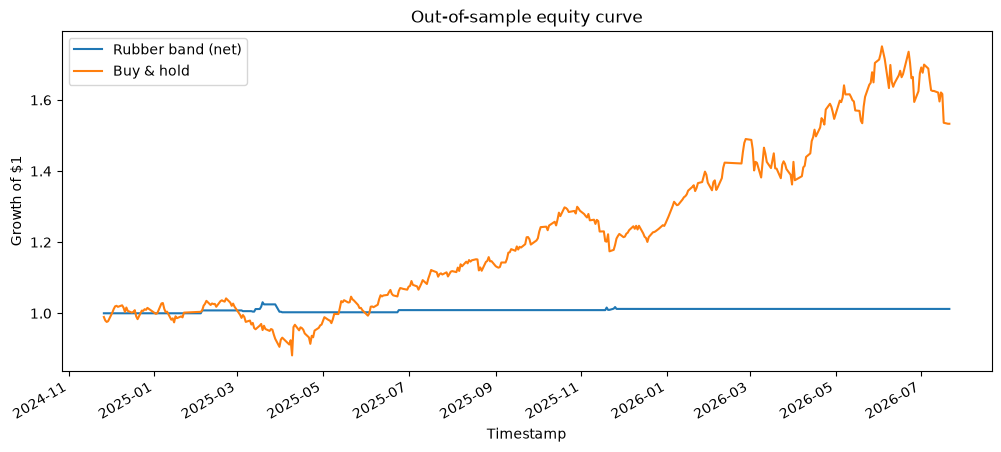

,day_divergence,night_divergence,hist_vol_40,pos_day,pos_night,gross_ret,cost,strat_ret
Timestamp,,,,,,,,
2025-02-04,-0.022583,-0.027600,0.006999,0.0,1.0,0.008093,0.00002,0.008073
2025-03-05,-0.030010,-0.019805,0.006888,0.0,1.0,-0.001991,0.00002,-0.002011
2025-03-12,-0.048126,-0.022131,0.007202,0.0,1.0,-0.001270,0.00002,-0.001290
2025-03-14,-0.049962,-0.013936,0.007709,-1.0,0.0,0.007188,0.00002,0.007168
2025-03-17,-0.045987,-0.007098,0.007666,-1.0,0.0,0.000135,0.00000,0.000135
2025-03-18,-0.035295,0.004424,0.007643,-1.0,0.0,0.006392,0.00000,0.006392
2025-03-19,-0.030445,0.005873,0.007639,-1.0,0.0,0.012321,0.00000,0.012321
2025-03-20,-0.039750,-0.003747,0.007867,-1.0,0.0,-0.005801,0.00000,-0.005801
2025-03-31,-0.039891,-0.021018,0.007327,0.0,1.0,-0.020161,0.00002,-0.020181


Test day-session trades: 12
Test night-session trades: 5


In [ ]:
test = result.loc[split_dates['test_start']:].copy()
equity = pd.DataFrame({
    'Rubber band (net)': (1 + test['strat_ret'].fillna(0)).cumprod(),
    'Buy & hold': (1 + test['benchmark_ret'].fillna(0)).cumprod(),
})
ax = equity.plot(figsize=(12, 5), title='Out-of-sample equity curve')
ax.set_ylabel('Growth of $1')
plt.show()

signal_log = test.loc[(test['pos_day'] != 0) | (test['pos_night'] != 0), [
    'day_divergence', 'night_divergence', 'hist_vol_40',
    'pos_day', 'pos_night', 'gross_ret', 'cost', 'strat_ret',
]]
display(signal_log.tail(30))
print('Test day-session trades:', int((test['pos_day'] != 0).sum()))
print('Test night-session trades:', int((test['pos_night'] != 0).sum()))
